In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
import pickle
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")


Libraries imported successfully


In [2]:
# Load Data
df = pd.read_csv('../data/processed/city_daily_clean.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['city', 'date']).reset_index(drop=True)

# Pollutant columns we will use
pollutants = ['PM25', 'PM10', 'NO', 'NO2', 'NOx', 'SO2', 'CO', 'Ozone', 'Benzene']

print("Shape:", df.shape)
print("Cities:", df['city'].unique())

Shape: (19018, 17)
Cities: <StringArray>
['Bengaluru', 'Delhi', 'Hyderabad', 'Mumbai']
Length: 4, dtype: str


In [3]:
# Build and train autoencoder per city
# Dictionary to store results per city
anomaly_results = {}
city_scalers = {}

cities = ['Delhi', 'Bengaluru', 'Mumbai', 'Hyderabad']

for city in cities:
    print(f"\nTraining Autoencoder for {city}...")

    # Get city data and drop nulls
    city_df = df[df['city'] == city][['date'] + pollutants].dropna().copy()
    city_df = city_df.sort_values('date').reset_index(drop=True)

    # Scale data
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(city_df[pollutants])
    city_scalers[city] = scaler

    # Build autoencoder
    # Encoder compresses data, decoder reconstructs it
    # High reconstruction error = anomaly
    n_features = scaled.shape[1]

    input_layer = Input(shape=(n_features,))

    # Encoder
    encoded = Dense(16, activation='relu')(input_layer)
    encoded = Dense(8, activation='relu')(encoded)
    encoded = Dense(4, activation='relu')(encoded)

    # Decoder
    decoded = Dense(8, activation='relu')(encoded)
    decoded = Dense(16, activation='relu')(decoded)
    decoded = Dense(n_features, activation='sigmoid')(decoded)

    autoencoder = Model(input_layer, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')

    # Train on normal data only (use 80% for training)
    split = int(len(scaled) * 0.8)
    X_train = scaled[:split]
    X_full = scaled

    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = autoencoder.fit(
        X_train, X_train,
        epochs=100,
        batch_size=32,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )

    # Reconstruction error for all data
    reconstructed = autoencoder.predict(X_full, verbose=0)
    mse_errors = np.mean(np.power(X_full - reconstructed, 2), axis=1)

    # Threshold is 95th percentile of training errors
    train_errors = mse_errors[:split]
    threshold = np.percentile(train_errors, 95)

    # Flag anomalies
    anomalies = mse_errors > threshold

    anomaly_results[city] = {
        'model': autoencoder,
        'dates': city_df['date'].values,
        'errors': mse_errors,
        'threshold': threshold,
        'anomalies': anomalies,
        'city_df': city_df,
        'history': history
    }

    print(f"  Training epochs: {len(history.history['loss'])}")
    print(f"  Threshold: {threshold:.6f}")
    print(f"  Anomalies detected: {anomalies.sum()} out of {len(anomalies)} days")


Training Autoencoder for Delhi...
  Training epochs: 100
  Threshold: 0.007471
  Anomalies detected: 341 out of 4838 days

Training Autoencoder for Bengaluru...
  Training epochs: 76
  Threshold: 0.004745
  Anomalies detected: 488 out of 4838 days

Training Autoencoder for Mumbai...
  Training epochs: 48
  Threshold: 0.011358
  Anomalies detected: 605 out of 4838 days

Training Autoencoder for Hyderabad...
  Training epochs: 67
  Threshold: 0.004480
  Anomalies detected: 127 out of 2739 days


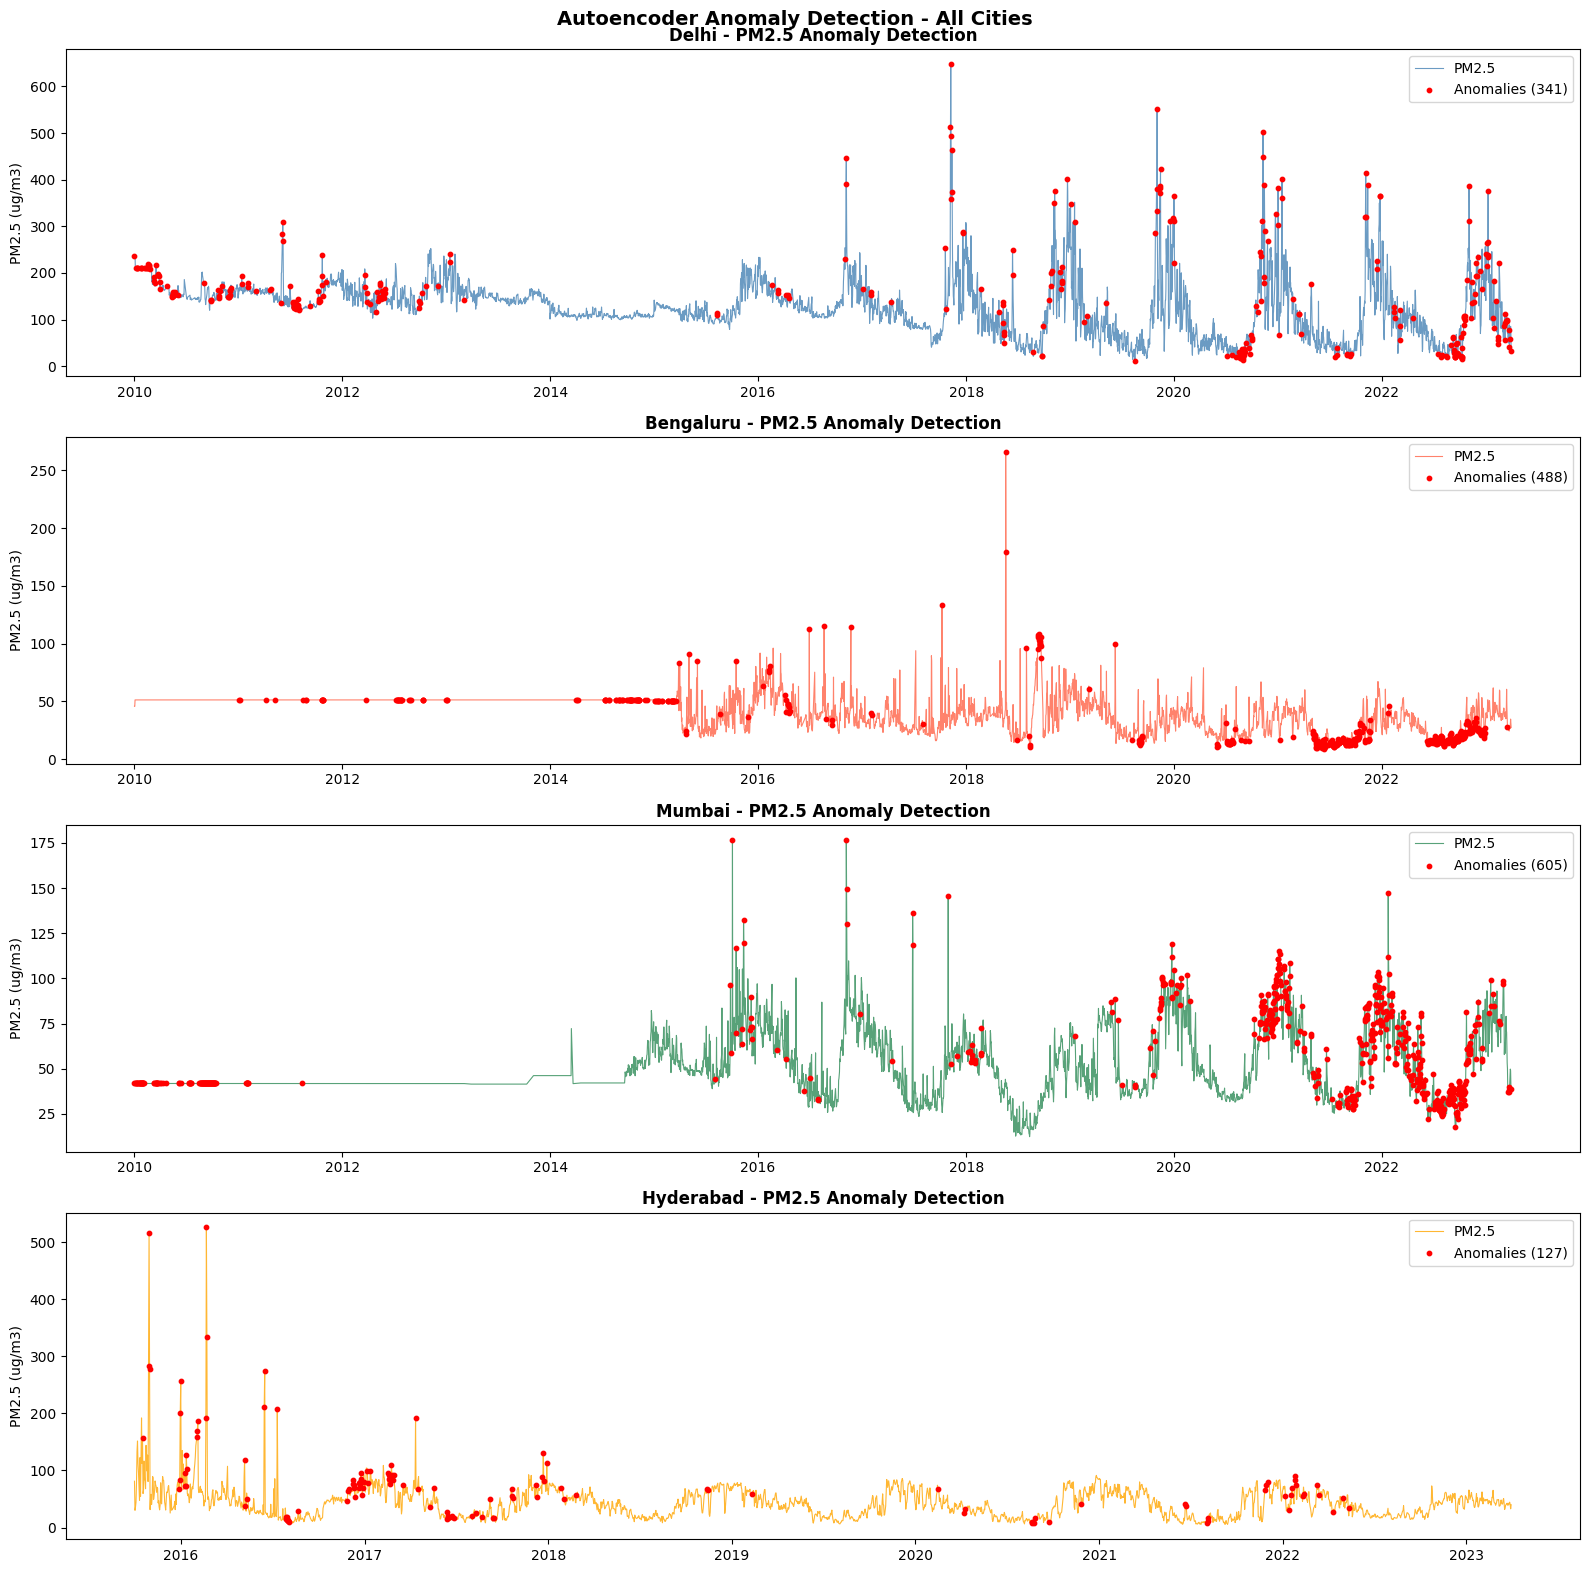

In [4]:
# Plot anomalies per city
fig, axes = plt.subplots(4, 1, figsize=(16, 16))
colors = ['steelblue', 'tomato', 'seagreen', 'orange']

for ax, city, color in zip(axes, cities, colors):
    res = anomaly_results[city]
    dates = pd.to_datetime(res['dates'])
    pm25 = res['city_df']['PM25'].values
    anomalies = res['anomalies']

    # Plot normal days
    ax.plot(dates, pm25, color=color, linewidth=0.8, label='PM2.5', alpha=0.8)

    # Highlight anomaly days in red
    ax.scatter(
        dates[anomalies],
        pm25[anomalies],
        color='red',
        s=10,
        zorder=5,
        label=f'Anomalies ({anomalies.sum()})'
    )

    ax.set_title(f'{city} - PM2.5 Anomaly Detection', fontweight='bold')
    ax.set_ylabel('PM2.5 (ug/m3)')
    ax.legend(loc='upper right')

plt.suptitle('Autoencoder Anomaly Detection - All Cities', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

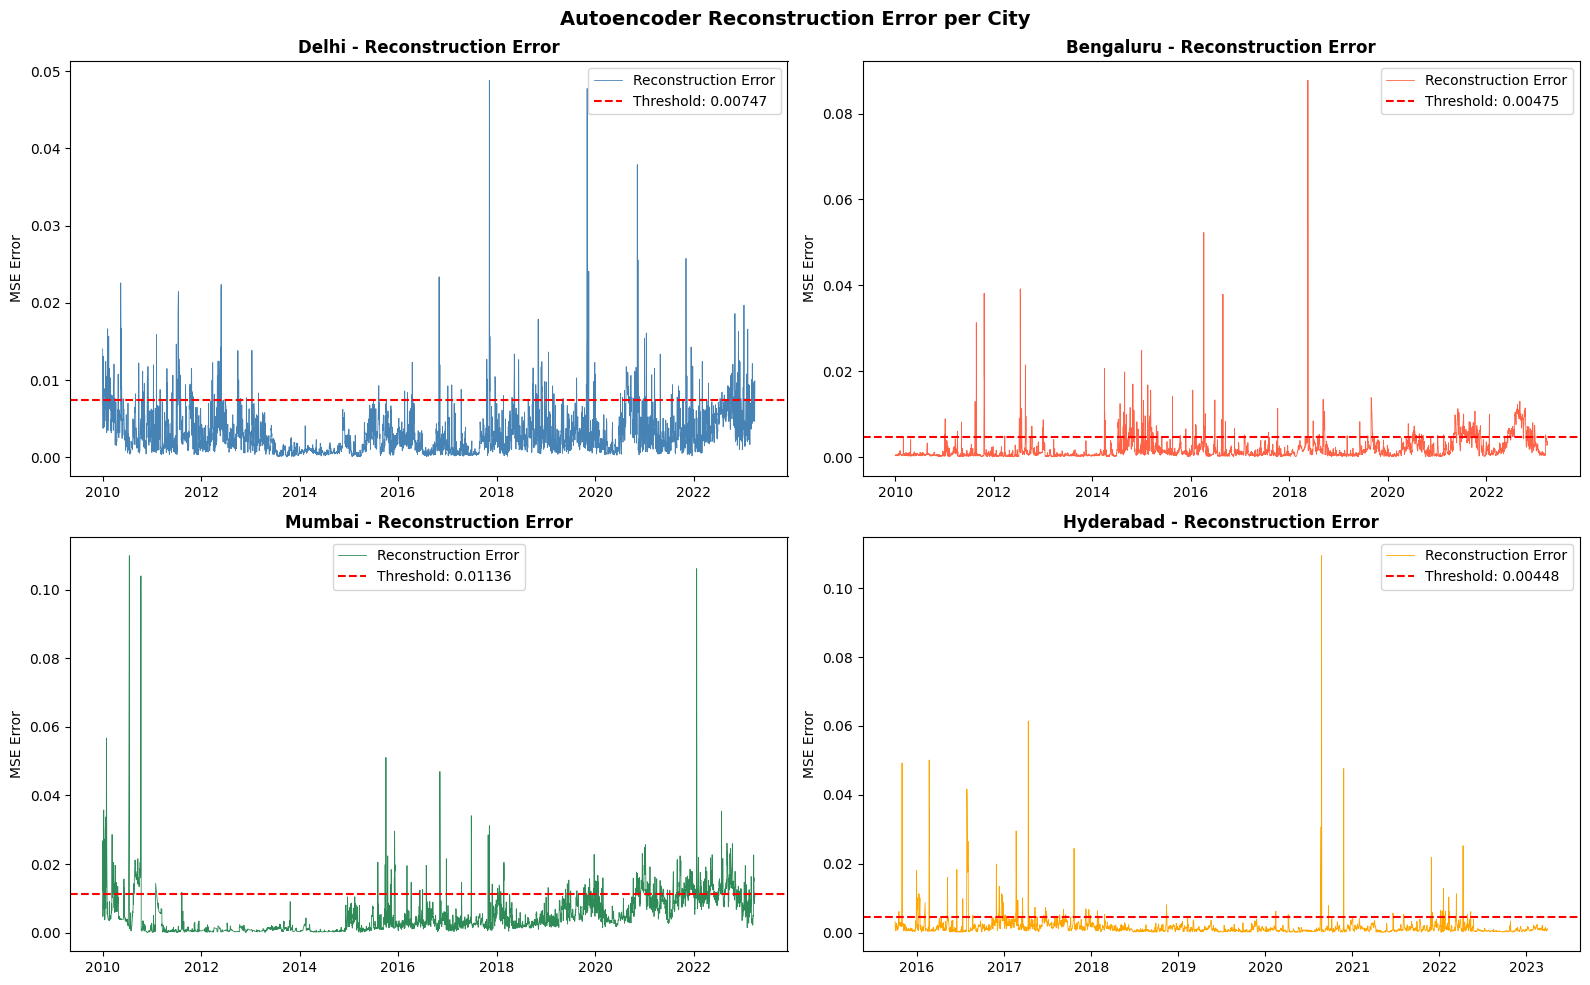

In [5]:
# Plot reconstruction error per city
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors = ['steelblue', 'tomato', 'seagreen', 'orange']

for ax, city, color in zip(axes.flatten(), cities, colors):
    res = anomaly_results[city]
    dates = pd.to_datetime(res['dates'])
    errors = res['errors']
    threshold = res['threshold']

    ax.plot(dates, errors, color=color, linewidth=0.6, label='Reconstruction Error')
    ax.axhline(y=threshold, color='red', linestyle='--', linewidth=1.5, label=f'Threshold: {threshold:.5f}')
    ax.set_title(f'{city} - Reconstruction Error', fontweight='bold')
    ax.set_ylabel('MSE Error')
    ax.legend()

plt.suptitle('Autoencoder Reconstruction Error per City', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
#  Find top anomaly dates per city
print("Top 10 Anomaly Dates per City")


top_anomalies = {}

for city in cities:
    res = anomaly_results[city]
    city_df = res['city_df'].copy()
    city_df['error'] = res['errors']
    city_df['is_anomaly'] = res['anomalies']

    # Get top 10 anomaly days sorted by error
    top = city_df[city_df['is_anomaly']].nlargest(10, 'error')[['date', 'PM25', 'error']]
    top_anomalies[city] = top

    print(f"\n{city}:")
    print(top.to_string(index=False))

Top 10 Anomaly Dates per City

Delhi:
      date       PM25    error
2017-11-08 647.718036 0.048819
2019-11-03 551.715569 0.047747
2020-11-09 502.356355 0.037887
2017-11-07 512.595736 0.027492
2021-11-05 413.793297 0.025753
2020-11-14 388.192682 0.025559
2019-11-15 422.444591 0.024095
2017-11-09 493.845108 0.023707
2016-10-31 229.902049 0.023378
2010-05-15 149.937803 0.022584

Bengaluru:
      date       PM25    error
2018-05-20 265.959176 0.087766
2016-04-08  40.407178 0.052305
2012-07-17  51.230321 0.039164
2011-10-23  51.230321 0.038146
2016-08-28  35.018376 0.037933
2011-08-26  51.230321 0.031303
2015-01-03  50.398877 0.024842
2018-05-21 179.431243 0.024586
2012-08-24  51.230321 0.021451
2014-04-02  51.230321 0.020615

Mumbai:
      date       PM25    error
2010-07-18  41.865000 0.110014
2022-01-23 147.126698 0.106230
2010-10-12  41.865000 0.104102
2010-10-11  41.865000 0.101480
2010-10-13  41.865000 0.096696
2010-07-17  41.865000 0.083690
2010-07-16  41.865000 0.062682
2010-01-29 

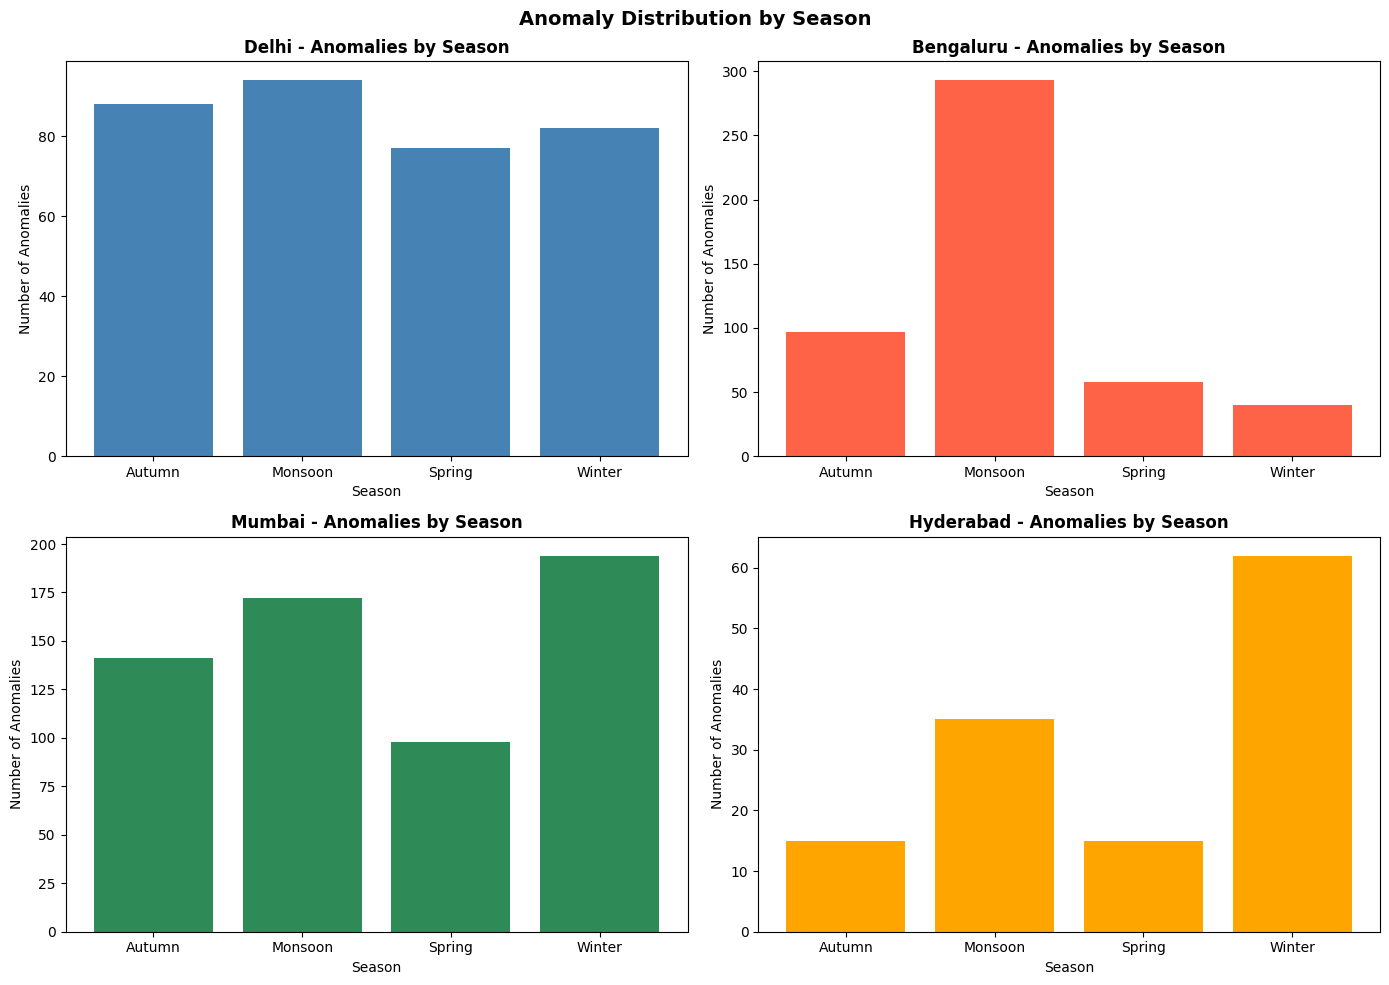

In [7]:
# Seasonal anomaly distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

season_map = {1: 'Winter', 2: 'Winter', 3: 'Spring',
              4: 'Spring', 5: 'Spring', 6: 'Monsoon',
              7: 'Monsoon', 8: 'Monsoon', 9: 'Monsoon',
              10: 'Autumn', 11: 'Autumn', 12: 'Winter'}

colors = ['steelblue', 'tomato', 'seagreen', 'orange']

for ax, city, color in zip(axes.flatten(), cities, colors):
    res = anomaly_results[city]
    city_df = res['city_df'].copy()
    city_df['is_anomaly'] = res['anomalies']
    city_df['season'] = city_df['date'].dt.month.map(season_map)

    # Count anomalies per season
    season_counts = city_df[city_df['is_anomaly']].groupby('season').size()

    ax.bar(season_counts.index, season_counts.values, color=color)
    ax.set_title(f'{city} - Anomalies by Season', fontweight='bold')
    ax.set_ylabel('Number of Anomalies')
    ax.set_xlabel('Season')

plt.suptitle('Anomaly Distribution by Season', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Save models and results
import os
import pickle

os.makedirs('../src/models', exist_ok=True)

for city in cities:
    # Save autoencoder model
    model_path = f'../src/models/autoencoder_{city.lower()}.keras'
    anomaly_results[city]['model'].save(model_path)
    print(f"Autoencoder saved for {city}")

# Save scalers and anomaly info
with open('../src/models/anomaly_scalers.pkl', 'wb') as f:
    pickle.dump(city_scalers, f)
print("Anomaly scalers saved")

# Save top anomalies
with open('../src/models/top_anomalies.pkl', 'wb') as f:
    pickle.dump(top_anomalies, f)
print("Top anomalies saved")

# Print summary
print("\nAnomaly Detection Summary:")

for city in cities:
    res = anomaly_results[city]
    total = len(res['anomalies'])
    detected = res['anomalies'].sum()
    pct = (detected / total) * 100
    print(f"{city:12} - Total days: {total}  Anomalies: {detected}  ({pct:.1f}%)")

Autoencoder saved for Delhi
Autoencoder saved for Bengaluru
Autoencoder saved for Mumbai
Autoencoder saved for Hyderabad
Anomaly scalers saved
Top anomalies saved

Anomaly Detection Summary:
Delhi        - Total days: 4838  Anomalies: 341  (7.0%)
Bengaluru    - Total days: 4838  Anomalies: 488  (10.1%)
Mumbai       - Total days: 4838  Anomalies: 605  (12.5%)
Hyderabad    - Total days: 2739  Anomalies: 127  (4.6%)
